In [1]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import lightning.pytorch as pl
import matplotlib.pyplot as plt

from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.models import TemporalFusionTransformer
from torch.utils.data import DataLoader

pl.seed_everything(42, workers=True)

project_root = r"C:\Users\admin\Desktop\Forex_algo\code"
if project_root not in sys.path:
    sys.path.append(project_root)

from technicals.indicators import add_standard_indicators

model_H1_path = r"C:\Users\admin\Desktop\Forex_algo\code\tft_ret_rich_v5.ckpt"
DATA_H1 = r"C:\Users\admin\Desktop\Forex_algo\code\Data\EUR_USD_H1.parquet"

device = torch.device("cpu")  # keep it simple on CPU
print("Using device:", device)


c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:28: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42


Using device: cpu


In [2]:
FEATURE_COLS_EXT = [
    "mid_o", "mid_h", "mid_l", "mid_c",
    "volume", "log_volume",
    "rsi",
    "macd", "macd_signal", "macd_hist",
    "atr14",
    "bb_lower", "bb_middle", "bb_upper",
    "ema_5", "ema_20", "ema_50", "ema_200",
    "momentum_oc", "avg_price_hl", "range_hl", "typical_price_ohlc",
]

def prepare_eurusd_df(raw_df: pd.DataFrame, series_id: str):
    df = raw_df.copy()
    df["time"] = pd.to_datetime(df["time"], utc=True)

    df["close"] = df["mid_c"]
    df["hour"] = df["time"].dt.hour.astype(str)
    df["day_of_week"] = df["time"].dt.dayofweek.astype(str)

    df["series_id"] = series_id
    df["time_idx"] = np.arange(len(df), dtype=int)

    # indicators from your technicals.indicators
    df = add_standard_indicators(df)

    # engineered features
    df["momentum_oc"] = df["mid_c"] - df["mid_o"]
    df["avg_price_hl"] = (df["mid_h"] + df["mid_l"]) / 2.0
    df["range_hl"] = df["mid_h"] - df["mid_l"]
    df["typical_price_ohlc"] = (
        df["mid_o"] + df["mid_h"] + df["mid_l"] + df["mid_c"]
    ) / 4.0

    df["log_volume"] = np.log1p(df["volume"])

    # target = next-bar log return
    df["target_return"] = np.log(df["close"].shift(-1)) - np.log(df["close"])

    df = df.dropna().reset_index(drop=True)
    return df


In [3]:
df_h1_raw = pd.read_parquet(DATA_H1)
df_h1 = prepare_eurusd_df(df_h1_raw, series_id="eurusd_h1")

print("H1 after features:", df_h1.shape)
print(df_h1[["time", "time_idx", "target_return"]].head())


H1 after features: (61273, 48)
                       time  time_idx  target_return
0 2016-01-19 07:00:00+00:00       199       0.001784
1 2016-01-19 08:00:00+00:00       200      -0.001121
2 2016-01-19 09:00:00+00:00       201       0.000055
3 2016-01-19 10:00:00+00:00       202      -0.000920
4 2016-01-19 11:00:00+00:00       203       0.001067


In [4]:
MAX_ENCODER_LENGTH_H1 = 168  # what you used in training
MAX_PRED_LENGTH_H1   = 1

h1_ds = TimeSeriesDataSet(
    df_h1,
    time_idx="time_idx",
    target="target_return",
    group_ids=["series_id"],
    max_encoder_length=MAX_ENCODER_LENGTH_H1,
    max_prediction_length=MAX_PRED_LENGTH_H1,
    time_varying_unknown_reals=FEATURE_COLS_EXT,
    time_varying_known_categoricals=["hour", "day_of_week"],
    static_categoricals=["series_id"],
    target_normalizer=None,
    allow_missing_timesteps=True,
    add_relative_time_idx=True,
    add_encoder_length=True,
    add_target_scales=False,
)

h1_dl = h1_ds.to_dataloader(train=False, batch_size=256, num_workers=0)
print("H1 samples:", len(h1_ds))


H1 samples: 61105


In [5]:
tft_h1 = TemporalFusionTransformer.load_from_checkpoint(
    model_H1_path,
    map_location=device,
)
tft_h1.to(device)
tft_h1.eval()


c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


TemporalFusionTransformer(
  	"attention_head_size":               4
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'target_return', 'group_ids': ['series_id'], 'weight': None, 'max_encoder_length': 168, 'min_encoder_length': 168, 'min_prediction_idx': 199, 'min_prediction_length': 1, 'max_prediction_length': 1, 'static_categoricals': ['series_id'], 'static_reals': None, 'time_varying_known_categoricals': ['hour', 'day_of_week'], 'time_varying_known_reals': None, 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['mid_o', 'mid_h', 'mid_l', 'mid_c', 'volume', 'log_volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr14', 'bb_lower', 'bb_middle', 'bb_upper', 'ema_5', 'ema_20', 'ema_50', 'ema_200', 'momentum_oc', 'avg_price_hl', 'range_hl', 'typical_price_ohlc'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': Tru

In [6]:
def get_preds_and_true_simple(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = model.predict(dataloader, mode="prediction")  # [N, max_pred_len] or [N, max_pred_len, 1]
    preds = preds.detach().cpu()

    if preds.ndim == 3:
        preds = preds.squeeze(-1)   # [N, max_pred_len]
    preds = preds.reshape(-1).numpy()

    ys = []
    for _, y in dataloader:
        if isinstance(y, torch.Tensor):
            ys.append(y.reshape(-1))
        elif isinstance(y, (list, tuple)):
            for item in y:
                if isinstance(item, torch.Tensor):
                    ys.append(item.reshape(-1))
                    break
        elif isinstance(y, dict):
            taken = False
            for v in y.values():
                if isinstance(v, torch.Tensor):
                    ys.append(v.reshape(-1))
                    taken = True
                    break
            if not taken:
                raise RuntimeError("No tensor target found in y dict")
        else:
            raise RuntimeError(f"Unsupported type for y: {type(y)}")

    y_true = torch.cat(ys).detach().cpu().numpy()

    # align lengths (just in case of padding)
    L = min(len(preds), len(y_true))
    preds = preds[:L]
    y_true = y_true[:L]

    return y_true, preds


In [7]:
y_true_h1, y_pred_h1 = get_preds_and_true_simple(tft_h1, h1_dl)

print("H1 preds:", y_pred_h1.shape, "true:", y_true_h1.shape)

def build_pred_df(df_base, y_true, y_pred):
    L = len(y_true)
    df_tail = df_base.tail(L).copy().reset_index(drop=True)
    df_tail["y_true"] = y_true
    df_tail["y_pred"] = y_pred
    return df_tail

df_pred_h1 = build_pred_df(df_h1, y_true_h1, y_pred_h1)
df_pred_h1[["time", "y_true", "y_pred"]].tail()


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoad

H1 preds: (61105,) true: (61105,)


,time,y_true,y_pred
61100,2025-11-21 16:00:00+00:00,0.000191,0.000293
61101,2025-11-21 17:00:00+00:00,-0.000261,0.000373
61102,2025-11-21 18:00:00+00:00,0.000791,0.000646
61103,2025-11-21 19:00:00+00:00,0.000373,0.001715
61104,2025-11-21 20:00:00+00:00,-0.000399,-0.000832


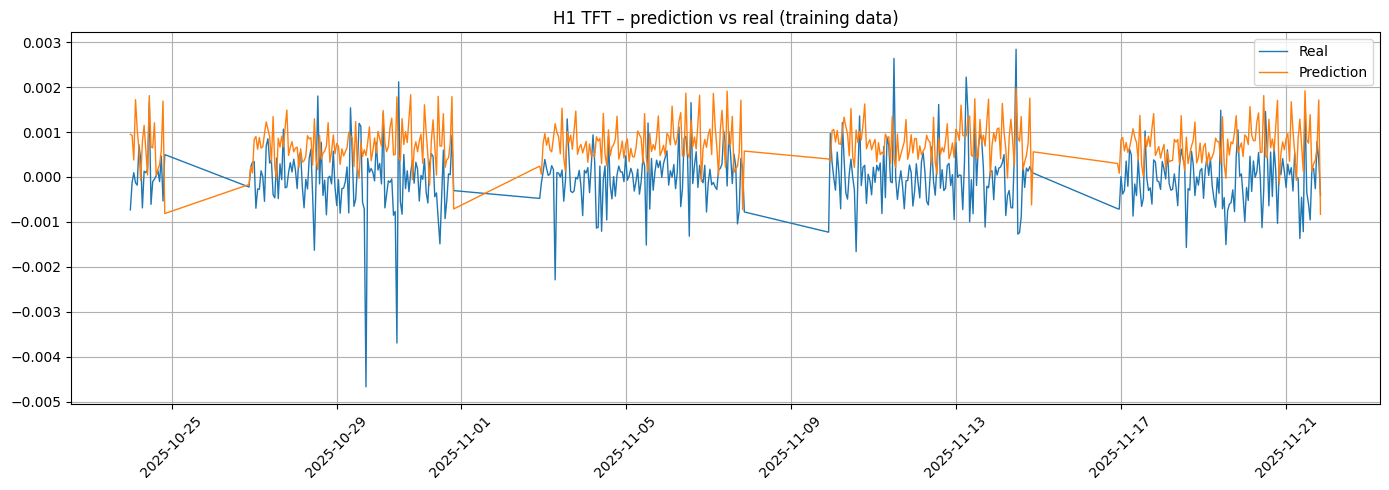

In [8]:
N = 500  # last N points

def plot_preds(df, title):
    df_plot = df.tail(N)
    x = df_plot["time"]

    plt.figure(figsize=(14, 5))
    plt.plot(x, df_plot["y_true"], label="Real", linewidth=1)
    plt.plot(x, df_plot["y_pred"], label="Prediction", linewidth=1)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_preds(df_pred_h1, "H1 TFT – prediction vs real (training data)")


In [9]:
import numpy as np

def regression_metrics(y_true, y_pred):
    mse = np.mean((y_pred - y_true) ** 2)
    mae = np.mean(np.abs(y_pred - y_true))

    # Direction accuracy: sign(pred) vs sign(true)
    sign_true = np.sign(y_true)
    sign_pred = np.sign(y_pred)

    # Option: ignore cases where true == 0 (no move)
    mask = sign_true != 0
    if mask.sum() > 0:
        dir_acc = (sign_true[mask] == sign_pred[mask]).mean()
    else:
        dir_acc = np.nan

    return mse, mae, dir_acc

mse_h1, mae_h1, dir_acc_h1 = regression_metrics(y_true_h1, y_pred_h1)

print("=== H1 – Full series metrics ===")
print(f"MSE: {mse_h1:.8f}")
print(f"MAE: {mae_h1:.8f}")
print(f"Direction accuracy (non-zero true): {dir_acc_h1*100:.2f}%")


=== H1 – Full series metrics ===
MSE: 0.00000185
MAE: 0.00105885
Direction accuracy (non-zero true): 50.15%


In [10]:
N = 2000  # choose the window you care about: 500, 2000, etc.

y_true_last = y_true_h1[-N:]
y_pred_last = y_pred_h1[-N:]

mse_last, mae_last, dir_acc_last = regression_metrics(y_true_last, y_pred_last)

print(f"\n=== H1 – Last {N} points ===")
print(f"MSE: {mse_last:.8f}")
print(f"MAE: {mae_last:.8f}")
print(f"Direction accuracy (non-zero true): {dir_acc_last*100:.2f}%")



=== H1 – Last 2000 points ===
MSE: 0.00000140
MAE: 0.00092523
Direction accuracy (non-zero true): 49.34%
